In [ ]:
# Configuration -- point this at wherever your fram_bulk_async.py run wrote
# its stats file (matches the --stats-path argument used for that run;
# default there is "upload_stats.csv" in the run's working directory).
STATS_PATH = "upload_stats.csv"

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import json, os, csv
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [4]:
# !!!global!!!
plt.style.use('default')
# plt.style.use('dark_background')

Upload stats analysis (FRAM):

In [7]:
df = pd.read_csv(STATS_PATH)
print(df.columns)
df.head()

Index(['key', 'recid', 'status', 'error', 'start_ts', 'duration_s',
       'file_count', 'zip_used', 'bytes_uploaded', 'checksum_md5'],
      dtype='str')


,key,recid,status,error,start_ts,duration_s,file_count,zip_used,bytes_uploaded,checksum_md5
0,cta-n/2021/20210409/03185/C0/20210410023204-36...,NaN,started,NaN,1.783947e+09,NaN,1,False,0,c05c29b288b3d120c924e387def5fd6f
1,cta-n/2021/20210409/03185/C0/20210410023222-48...,NaN,started,NaN,1.783947e+09,NaN,1,False,0,419e9cbe5f808e5ee2504eec8bb6dafd
2,cta-n/2021/20210409/03185/C0/20210410023400-17...,NaN,started,NaN,1.783947e+09,NaN,1,False,0,2f4836d63a52e8dbedf84b87f58a9fca
3,cta-n/2021/20210409/03185/C0/20210410023250-56...,NaN,started,NaN,1.783947e+09,NaN,1,False,0,dd2f4d80bae120d2b6405c13d55258ab
4,cta-n/2021/20210409/03185/C0/20210410023250-56...,378xv-97y14,ok,NaN,1.783947e+09,4.968,1,False,976320,dd2f4d80bae120d2b6405c13d55258ab


In [8]:
df.describe()

,error,start_ts,duration_s,file_count,bytes_uploaded
count,0.0,1.200000e+01,6.000000,12.0,12.000000
mean,NaN,1.783947e+09,4.001000,1.0,432720.000000
std,NaN,2.455040e+00,1.533815,0.0,455881.224723
min,NaN,1.783947e+09,2.003000,1.0,0.000000
25%,NaN,1.783947e+09,2.771250,1.0,0.000000
50%,NaN,1.783947e+09,4.976000,1.0,393120.000000
75%,NaN,1.783947e+09,4.996000,1.0,833040.000000
max,NaN,1.783947e+09,5.012000,1.0,976320.000000


## Normalize machine-generated schema

In [9]:
d = df.copy()

# normalize known columns
d["key"] = d["key"].astype(str)
d["status"] = d["status"].astype(str).str.strip().str.lower()
d["error"] = d["error"].astype(str).replace({"nan": ""})

for c in ["bytes_uploaded", "duration_s", "file_count", "recid"]:
    d[c] = pd.to_numeric(d[c], errors="coerce")

# robust timestamp parsing (ISO or unix epoch)
start_raw = pd.to_numeric(d["start_ts"], errors="coerce")
if start_raw.notna().mean() > 0.95:
    # likely unix epoch; detect seconds vs ms by magnitude
    unit = "ms" if start_raw.median() > 1e11 else "s"
    d["start_dt"] = pd.to_datetime(start_raw, unit=unit, errors="coerce", utc=True)
else:
    d["start_dt"] = pd.to_datetime(d["start_ts"], errors="coerce", utc=True)

# normalize booleans from machine output (always False for FRAM -- one file
# per record, kept for schema compatibility with the DELPHI-style stats file)
d["zip_used"] = d["zip_used"].astype(str).str.strip().str.lower().map(
    {"true": True, "false": False, "1": True, "0": False}
)
d["zip_used"] = d["zip_used"].fillna(False)

# derived metrics -- duration_s is NaN only for "started" rows (no terminal
# timing yet). It IS populated for skipped_invalid/dryrun too, since those
# still measure checksum+extract time locally. bytes_uploaded is 0 for
# started/failed/skipped_invalid, but for dryrun it's set to the local file
# size as a preview of "what would be uploaded" -- NOT an actual transfer.
# Filter to status == "ok" for genuine upload throughput/size analysis (the
# KPI/graph cells below already do this).
d.loc[d["duration_s"] <= 0, "duration_s"] = np.nan
d["throughput_Bps"] = d["bytes_uploaded"] / d["duration_s"]
d["throughput_MBps"] = d["throughput_Bps"] / (1024**2)
d["bytes_uploaded_GiB"] = d["bytes_uploaded"] / (1024**3)

d.head()

,key,recid,status,error,start_ts,duration_s,file_count,zip_used,bytes_uploaded,checksum_md5,start_dt,throughput_Bps,throughput_MBps,bytes_uploaded_GiB
0,cta-n/2021/20210409/03185/C0/20210410023204-36...,NaN,started,NaN,1.783947e+09,NaN,1,False,0,c05c29b288b3d120c924e387def5fd6f,2026-07-13 12:53:08.752685547+00:00,NaN,NaN,0.000000
1,cta-n/2021/20210409/03185/C0/20210410023222-48...,NaN,started,NaN,1.783947e+09,NaN,1,False,0,419e9cbe5f808e5ee2504eec8bb6dafd,2026-07-13 12:53:08.755716801+00:00,NaN,NaN,0.000000
2,cta-n/2021/20210409/03185/C0/20210410023400-17...,NaN,started,NaN,1.783947e+09,NaN,1,False,0,2f4836d63a52e8dbedf84b87f58a9fca,2026-07-13 12:53:08.756683826+00:00,NaN,NaN,0.000000
3,cta-n/2021/20210409/03185/C0/20210410023250-56...,NaN,started,NaN,1.783947e+09,NaN,1,False,0,dd2f4d80bae120d2b6405c13d55258ab,2026-07-13 12:53:08.756230831+00:00,NaN,NaN,0.000000
4,cta-n/2021/20210409/03185/C0/20210410023250-56...,NaN,ok,NaN,1.783947e+09,4.968,1,False,976320,dd2f4d80bae120d2b6405c13d55258ab,2026-07-13 12:53:08.756230831+00:00,196521.73913,0.187418,0.000909


## Current status per file

`fram_bulk_async.py` resumes across runs, so a single `key` (relative file
path) can have several rows over time -- e.g. `started` -> `failed` on one
run, then `started` -> `ok` on a later run. The row-level data above still
reflects real events (useful for throughput/duration analysis), but to know
the *current* state of each file, collapse to the latest row per key.

In [10]:
# NOTE: deliberately NOT sorted by start_dt before taking the last row per
# key. A file's "started" row and its own terminal row (ok/failed/etc.)
# share the exact same start_ts (captured once, before either write), so a
# timestamp-based sort can tie -- and pandas' default sort isn't guaranteed
# stable, which could occasionally pick the wrong row. The stats CSV is
# strictly append-only, so the file's natural read order already IS true
# write order; relying on that directly is both simpler and correct.
latest = d.groupby("key", as_index=False).tail(1).copy()

print(f"{len(d)} total stats rows across {d['key'].nunique()} unique files")
print(f"{len(latest)} files after collapsing to latest known state per file")
latest["status"].value_counts()

12 total stats rows across 6 unique files
6 files after collapsing to latest known state per file


status
ok    6
Name: count, dtype: int64

## Interrupted files (possible orphaned drafts)

Mirrors `fram_bulk_async.py`'s `_scan_stats()`: a key with a `started` row
but no terminal row (`ok` / `failed` / `skipped_invalid` / `dryrun`)
anywhere in its history means a previous run was interrupted mid-upload for
that file. It may have created an orphaned draft record in the repository
-- worth checking manually if this list is non-empty.

In [11]:
TERMINAL_STATUSES = {"ok", "failed", "skipped_invalid", "dryrun"}

by_key_statuses = d.groupby("key")["status"].apply(set)
started_keys = set(by_key_statuses[by_key_statuses.apply(lambda s: "started" in s)].index)
terminal_keys = set(by_key_statuses[by_key_statuses.apply(lambda s: bool(s & TERMINAL_STATUSES))].index)
interrupted_keys = started_keys - terminal_keys

print(f"{len(interrupted_keys)} file(s) currently show as interrupted:")
for k in sorted(interrupted_keys)[:50]:
    print(" ", k)

0 file(s) currently show as interrupted:


## KPI summary

In [12]:
ok_mask = d["status"].eq("ok")
failed_mask = d["status"].eq("failed")
skipped_mask = d["status"].eq("skipped_invalid")
dryrun_mask = d["status"].eq("dryrun")
started_mask = d["status"].eq("started")

ok_rows = int(ok_mask.sum())
failed_rows = int(failed_mask.sum())
skipped_rows = int(skipped_mask.sum())
dryrun_rows = int(dryrun_mask.sum())
started_rows = int(started_mask.sum())
attempted_rows = ok_rows + failed_rows  # rows that actually reached create()/upload()/publish()

summary = pd.DataFrame(
    {
        "metric": [
            "stats_rows_total",
            "unique_files_seen",
            "rows_ok",
            "rows_failed",
            "rows_skipped_invalid",
            "rows_dryrun",
            "rows_started",
            "files_currently_interrupted",
            "success_rate_pct_of_attempted",
            "uploaded_TiB_ok",
            "duration_p50_s_ok",
            "duration_p95_s_ok",
            "throughput_p50_MBps_ok",
            "throughput_p95_MBps_ok",
        ],
        "value": [
            len(d),
            d["key"].nunique(),
            ok_rows,
            failed_rows,
            skipped_rows,
            dryrun_rows,
            started_rows,
            len(interrupted_keys),
            (ok_rows / attempted_rows * 100) if attempted_rows else np.nan,
            d.loc[ok_mask, "bytes_uploaded"].fillna(0).sum() / (1024**4),
            d.loc[ok_mask, "duration_s"].dropna().quantile(0.50),
            d.loc[ok_mask, "duration_s"].dropna().quantile(0.95),
            d.loc[ok_mask, "throughput_MBps"].replace([np.inf, -np.inf], np.nan).dropna().quantile(0.50),
            d.loc[ok_mask, "throughput_MBps"].replace([np.inf, -np.inf], np.nan).dropna().quantile(0.95),
        ],
    }
)
summary

,metric,value
0,stats_rows_total,12.000000
1,unique_files_seen,6.000000
2,rows_ok,6.000000
3,rows_failed,0.000000
4,rows_skipped_invalid,0.000000
5,rows_dryrun,0.000000
6,rows_started,6.000000
7,files_currently_interrupted,0.000000
8,success_rate_pct_of_attempted,100.000000
9,uploaded_TiB_ok,0.000005


In [13]:
status_breakdown = (
    d.groupby("status", dropna=False)
    .agg(
        rows=("key", "count"),
        unique_files=("key", "nunique"),
        total_gib=("bytes_uploaded_GiB", "sum"),
        avg_duration_s=("duration_s", "mean"),
        p95_duration_s=("duration_s", lambda s: s.quantile(0.95)),
        avg_throughput_mbps=("throughput_MBps", "mean"),
    )
    .sort_values("rows", ascending=False)
)
status_breakdown

,rows,unique_files,total_gib,avg_duration_s,p95_duration_s,avg_throughput_mbps
status,,,,,,
ok,6,6,0.004836,4.001,5.009,0.250156
started,6,6,0.000000,NaN,NaN,NaN


## Graphs

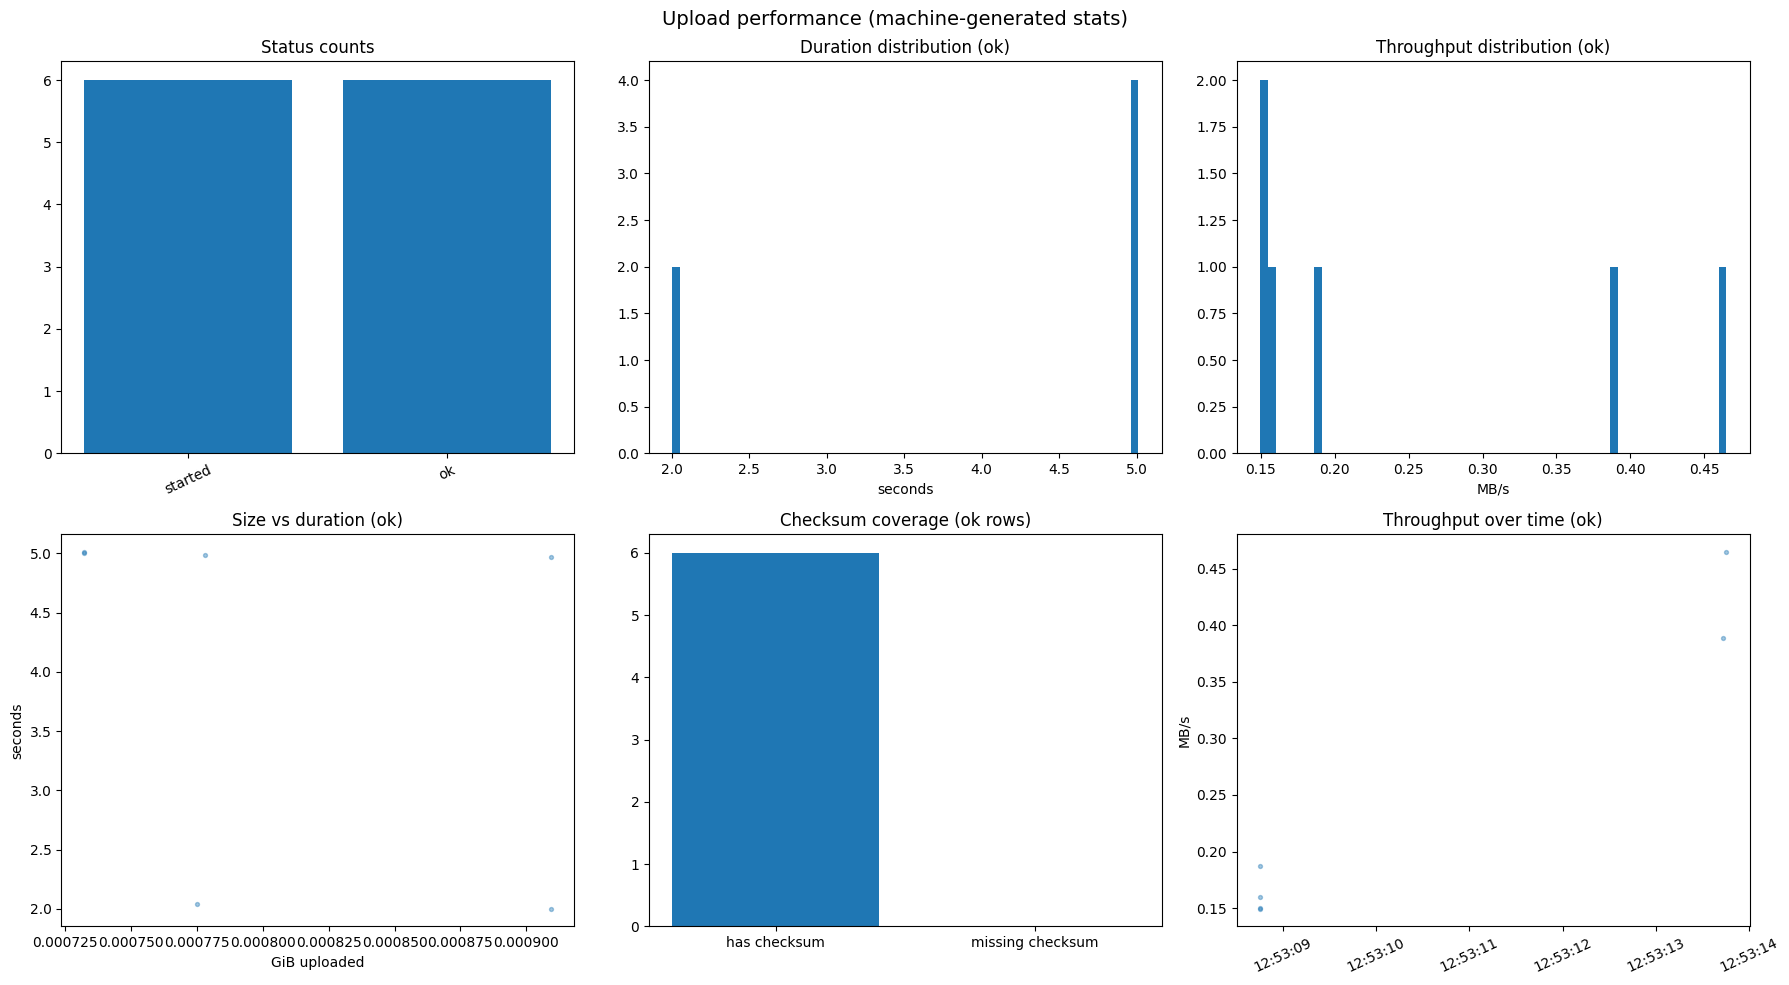

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Upload performance (machine-generated stats)", fontsize=14)

# 1) status count
sc = d["status"].value_counts(dropna=False)
axes[0, 0].bar(sc.index.astype(str), sc.values)
axes[0, 0].set_title("Status counts")
axes[0, 0].tick_params(axis="x", rotation=25)

# 2) duration histogram
axes[0, 1].hist(d.loc[ok_mask, "duration_s"].dropna(), bins=60)
axes[0, 1].set_title("Duration distribution (ok)")
axes[0, 1].set_xlabel("seconds")

# 3) throughput histogram
thr = d.loc[ok_mask, "throughput_MBps"].replace([np.inf, -np.inf], np.nan).dropna()
axes[0, 2].hist(thr, bins=60)
axes[0, 2].set_title("Throughput distribution (ok)")
axes[0, 2].set_xlabel("MB/s")

# 4) bytes vs duration
pts = d.loc[ok_mask, ["bytes_uploaded_GiB", "duration_s"]].dropna()
axes[1, 0].scatter(pts["bytes_uploaded_GiB"], pts["duration_s"], s=8, alpha=0.4)
axes[1, 0].set_title("Size vs duration (ok)")
axes[1, 0].set_xlabel("GiB uploaded")
axes[1, 0].set_ylabel("seconds")

# 5) checksum coverage -- every ok row should have one; flags a bug if not
has_checksum = d.loc[ok_mask, "checksum_md5"].notna() & d.loc[ok_mask, "checksum_md5"].astype(str).ne("")
axes[1, 1].bar(["has checksum", "missing checksum"], [has_checksum.sum(), (~has_checksum).sum()])
axes[1, 1].set_title("Checksum coverage (ok rows)")

# 6) throughput over time
tpts = d.loc[ok_mask, ["start_dt", "throughput_MBps"]].replace([np.inf, -np.inf], np.nan).dropna()
axes[1, 2].scatter(tpts["start_dt"], tpts["throughput_MBps"], s=8, alpha=0.4)
axes[1, 2].set_title("Throughput over time (ok)")
axes[1, 2].set_ylabel("MB/s")
axes[1, 2].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

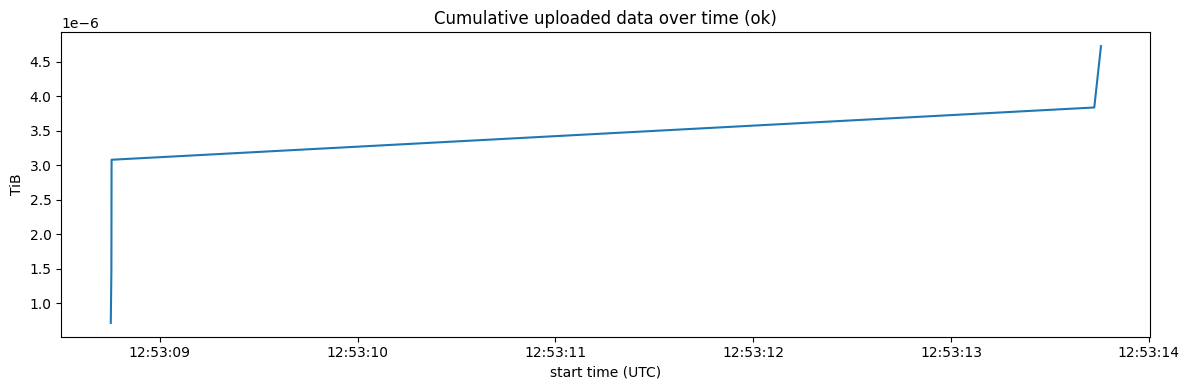

In [15]:
# cumulative uploaded TiB over time (ok only)
t = d.loc[ok_mask, ["start_dt", "bytes_uploaded"]].dropna().sort_values("start_dt").copy()
if not t.empty:
    t["cum_tib"] = t["bytes_uploaded"].cumsum() / (1024**4)
    plt.figure(figsize=(12, 4))
    plt.plot(t["start_dt"], t["cum_tib"])
    plt.title("Cumulative uploaded data over time (ok)")
    plt.xlabel("start time (UTC)")
    plt.ylabel("TiB")
    plt.tight_layout()
    plt.show()

In [16]:
# top slowest and top largest uploads -- restricted to status == "ok" so
# dryrun rows (which carry a real local file size and a small nonzero
# duration_s, despite never touching the network) can't show up here
display_cols = ["key", "recid", "status", "bytes_uploaded_GiB", "duration_s", "throughput_MBps", "checksum_md5", "error"]
print("Top 20 slowest (status == ok):")
display(d.loc[ok_mask, display_cols].sort_values("duration_s", ascending=False).head(20))

print("Top 20 largest (status == ok):")
display(d.loc[ok_mask, display_cols].sort_values("bytes_uploaded_GiB", ascending=False).head(20))

Top 20 slowest (status == ok):


,key,recid,status,bytes_uploaded_GiB,duration_s,throughput_MBps,checksum_md5,error
7,cta-n/2021/20210409/03185/C0/20210410023204-36...,NaN,ok,0.000732,5.012,0.149604,c05c29b288b3d120c924e387def5fd6f,NaN
6,cta-n/2021/20210409/03185/C0/20210410023400-17...,NaN,ok,0.000732,5.000,0.149963,2f4836d63a52e8dbedf84b87f58a9fca,NaN
5,cta-n/2021/20210409/03185/C0/20210410023222-48...,NaN,ok,0.000778,4.984,0.159813,419e9cbe5f808e5ee2504eec8bb6dafd,NaN
4,cta-n/2021/20210409/03185/C0/20210410023250-56...,NaN,ok,0.000909,4.968,0.187418,dd2f4d80bae120d2b6405c13d55258ab,NaN
11,cta-n/2021/20210409/03185/C0/20210410023418-31...,NaN,ok,0.000775,2.039,0.389290,07bd6ab40dd83197eb7d42e36a7507cd,NaN
10,cta-n/2021/20210409/03185/C0/20210410023446-45...,NaN,ok,0.000909,2.003,0.464848,d42adfa93b024267eeaf6aeb1cf3241b,NaN


Top 20 largest (status == ok):


,key,recid,status,bytes_uploaded_GiB,duration_s,throughput_MBps,checksum_md5,error
4,cta-n/2021/20210409/03185/C0/20210410023250-56...,NaN,ok,0.000909,4.968,0.187418,dd2f4d80bae120d2b6405c13d55258ab,NaN
10,cta-n/2021/20210409/03185/C0/20210410023446-45...,NaN,ok,0.000909,2.003,0.464848,d42adfa93b024267eeaf6aeb1cf3241b,NaN
5,cta-n/2021/20210409/03185/C0/20210410023222-48...,NaN,ok,0.000778,4.984,0.159813,419e9cbe5f808e5ee2504eec8bb6dafd,NaN
11,cta-n/2021/20210409/03185/C0/20210410023418-31...,NaN,ok,0.000775,2.039,0.389290,07bd6ab40dd83197eb7d42e36a7507cd,NaN
7,cta-n/2021/20210409/03185/C0/20210410023204-36...,NaN,ok,0.000732,5.012,0.149604,c05c29b288b3d120c924e387def5fd6f,NaN
6,cta-n/2021/20210409/03185/C0/20210410023400-17...,NaN,ok,0.000732,5.000,0.149963,2f4836d63a52e8dbedf84b87f58a9fca,NaN


---
## Manifest comparison (legacy / DELPHI-oriented)

The cells below compare two directory manifests by (path, size), including
logic to ignore folders containing a `*_bundle.zip` (DELPHI's >20-file
bundling behavior). FRAM never bundles files into zips -- one FITS file is
always one record -- so the bundle-folder-skipping step is a no-op for FRAM
data, but the manifest-diffing pattern itself may still be useful if you
ever want to compare two snapshots of the FRAM archive directory. Left here
unmodified from the DELPHI version; adapt `man1_path`/`man2_path` if used.

In [17]:
man1_path = "../stats/manifest1.txt"
man2_path = "../stats/manifest2.txt"

In [18]:
def _normalize_manifest_path(p: str) -> str:
    p = str(p).strip()
    parts = p.split("/", 1)
    return parts[1] if len(parts) == 2 else parts[0]

def _load_manifest(path: str) -> pd.DataFrame:
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split("|")
            if len(parts) < 2:
                continue
            raw_path = parts[0].strip()
            size = pd.to_numeric(parts[1], errors="coerce")  # keep size, ignore timestamp
            rows.append(
                {
                    "raw_path": raw_path,
                    "norm_path": _normalize_manifest_path(raw_path),
                    "size": np.nan if pd.isna(size) else int(size),
                }
            )
    return pd.DataFrame(rows)

m1 = _load_manifest(man1_path)
m2 = _load_manifest(man2_path)

print(f"manifest1 rows: {len(m1):,}")
print(f"manifest2 rows: {len(m2):,}")
m1.head()

FileNotFoundError: [Errno 2] No such file or directory: '../stats/manifest1.txt'

In [19]:
# Ignore all folders that contain xxx_bundle.zip (in either manifest)
def _folders_with_bundle_zip(df: pd.DataFrame) -> set[str]:
    mask = df["norm_path"].astype(str).str.contains(r".*_bundle\.zip$", regex=True, na=False)
    return set(df.loc[mask, "norm_path"].str.rsplit("/", n=1).str[0])

def _drop_folders(df: pd.DataFrame, folders: set[str]) -> pd.DataFrame:
    parents = df["norm_path"].astype(str).str.rsplit("/", n=1).str[0]
    return df.loc[~parents.isin(folders)].copy()

ignored_folders = _folders_with_bundle_zip(m1) | _folders_with_bundle_zip(m2)

m1_no_bundle = _drop_folders(m1, ignored_folders)
m2_no_bundle = _drop_folders(m2, ignored_folders)

print(f"Ignored folders: {len(ignored_folders):,}")
print(f"manifest1 filtered rows: {len(m1_no_bundle):,} / {len(m1):,}")
print(f"manifest2 filtered rows: {len(m2_no_bundle):,} / {len(m2):,}")

# Use filtered manifests for subsequent comparison cells
m1 = m1_no_bundle
m2 = m2_no_bundle

NameError: name 'm1' is not defined

In [20]:
# Exact compare by (normalized path + size), timestamp ignored
kcols = ["norm_path", "size"]
m1k = m1[kcols].drop_duplicates()
m2k = m2[kcols].drop_duplicates()

only_m1 = m1k.merge(m2k, on=kcols, how="left", indicator=True).query("_merge == 'left_only'").drop(columns="_merge")
only_m2 = m2k.merge(m1k, on=kcols, how="left", indicator=True).query("_merge == 'left_only'").drop(columns="_merge")

# Size mismatch compare by normalized path only
s1 = m1.groupby("norm_path", dropna=False)["size"].agg(lambda x: tuple(sorted(set([int(v) for v in x.dropna().tolist()])))).rename("sizes_m1")
s2 = m2.groupby("norm_path", dropna=False)["size"].agg(lambda x: tuple(sorted(set([int(v) for v in x.dropna().tolist()])))).rename("sizes_m2")
size_cmp = pd.concat([s1, s2], axis=1)
size_mismatch = size_cmp[
    size_cmp["sizes_m1"].notna() &
    size_cmp["sizes_m2"].notna() &
    (size_cmp["sizes_m1"] != size_cmp["sizes_m2"])
].reset_index()

summary_cmp = pd.DataFrame(
    {
        "metric": [
            "manifest1_unique_(path,size)",
            "manifest2_unique_(path,size)",
            "only_in_manifest1_(path,size)",
            "only_in_manifest2_(path,size)",
            "size_mismatch_same_norm_path",
        ],
        "value": [
            len(m1k),
            len(m2k),
            len(only_m1),
            len(only_m2),
            len(size_mismatch),
        ],
    }
)
summary_cmp

NameError: name 'm1' is not defined

In [ ]:
print("Only in manifest1 (sample):")
display(only_m1.head(50))

print("Only in manifest2 (sample):")
display(only_m2.head(50))

print("Same normalized path but different size sets (sample):")
display(size_mismatch.head(50))